# Import des bibliothèques nécessaires

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Présentation de la problématique et importation des données

## Présentation de la problématique


Le jeu de données "California Housing" contient des informations sur les logements en Californie, aux États-Unis, ainsi que leur valeur. 
L'objectif de ce jeu de projet **prédire la valeur des logements en fonction de leurs caractéristiques**.



Le fichier de données peut être téléchargé à partir de la page Kaggle suivante : [California Housing](https://www.kaggle.com/harrywang/housing)



Les variables présentes dans le jeu de données sont les suivantes :

- `longitude` : Longitude de la localisation du logement
- `latitude` : Latitude de la localisation du logement
- `housing_median_age` : Âge médian des logements dans la région
- `total_rooms` : Nombre total de chambres dans la région
- `total_bedrooms` : Nombre total de chambres à coucher dans la région
- `population` : Population totale dans la région
- `households` : Nombre total de ménages dans la région
- `median_income` : Revenu médian des ménages dans la région
- `median_house_value` : Valeur médiane des maisons dans la région
- `ocean_proximity` : Proximité de la maison par rapport à l'océan (côte, île, etc.)









## Importation et nettoyage des données

In [2]:
import pandas as pd
data = pd.read_csv('housing.csv',sep=";",deceimal=",")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [4]:
#Information sur la base de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(5), int64(4), object(1)
memory usage: 1.6+ MB


In [5]:
#Analyse des données manquantes
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Description des tables
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
# On suppose que les régions qui ont la variable total_bedooms manquantes n'ont pas de chambre
# Remplacement des valeurs manquantes par 0 pour la variable 'total_bedrooms'
data['total_bedrooms'].fillna(0, inplace=True)
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Description des biens de la base de données

## Description des variables numériques

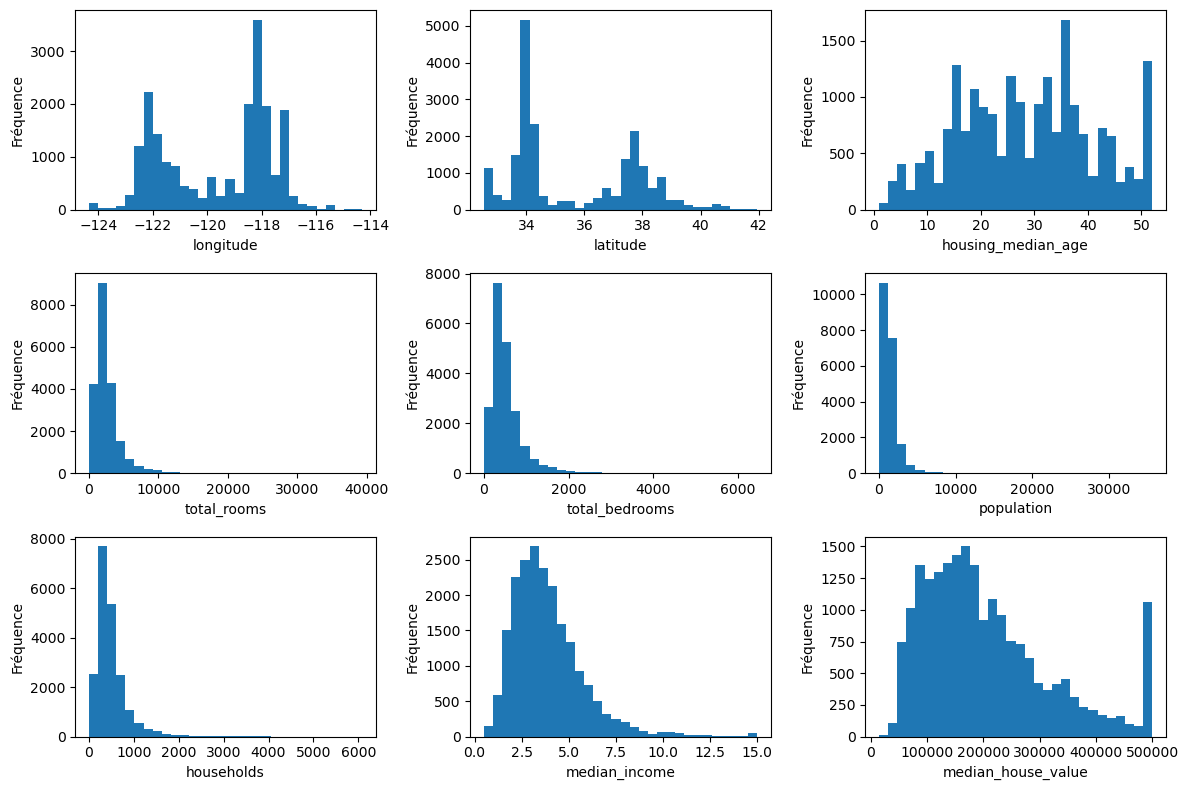

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as  np
# Description univariée des variables numériques

# Sélection des variables quantitatives
quant_vars = data.select_dtypes(include=np.number).columns

# Création des subplots pour chaque variable quantitative sur une même figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].hist(data[var], bins=30)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()


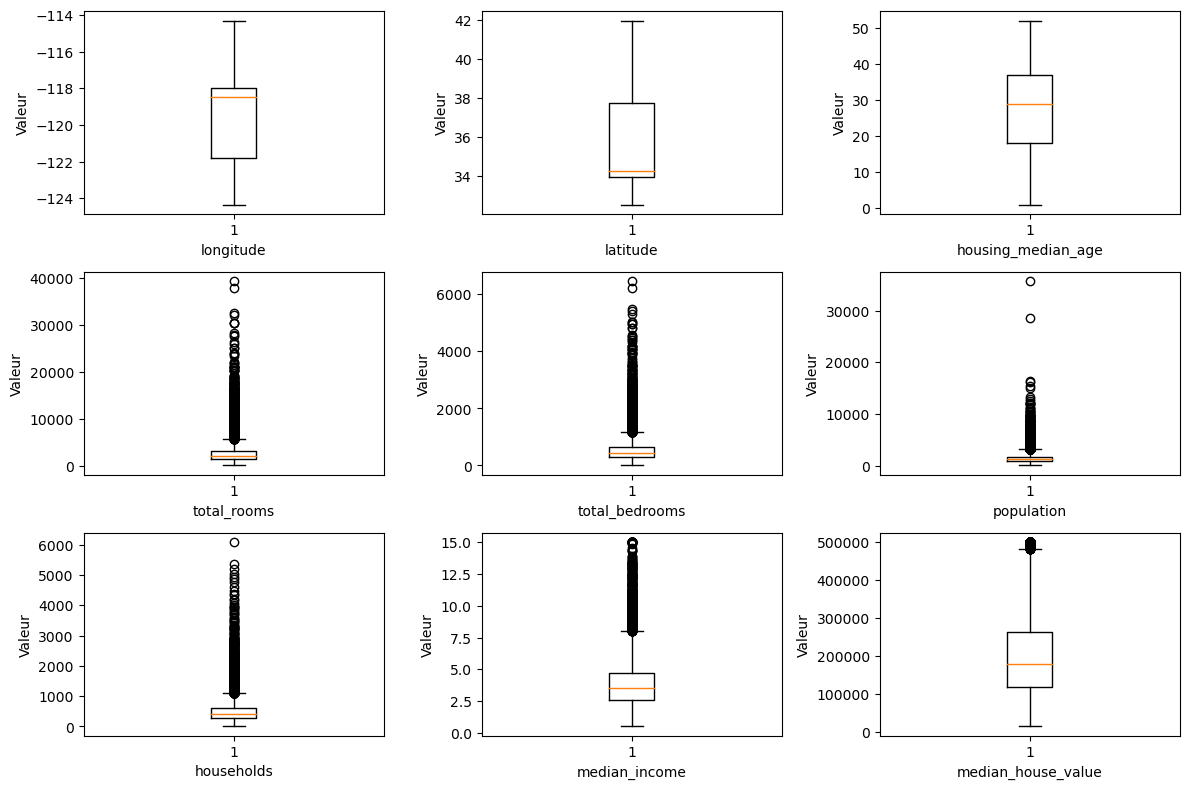

In [9]:
quant_vars = data.select_dtypes(include=np.number).columns
# Création des subplots pour chaque variable quantitative sur une même figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].boxplot(data[var])
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Valeur')
plt.tight_layout()
plt.show()

## Description de la variable catégorielle 'ocean_proximity'

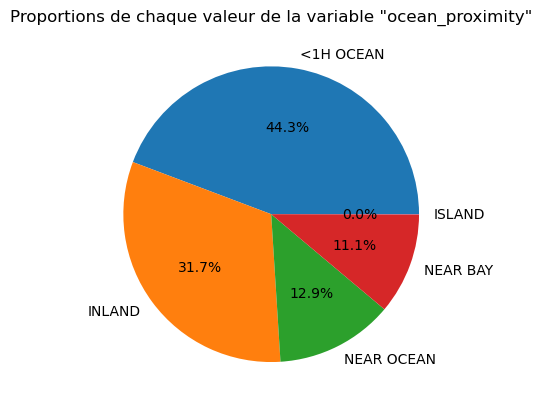

In [10]:


# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Création du pie chart
plt.pie(prop_counts, labels=prop_counts.index, autopct='%1.1f%%')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

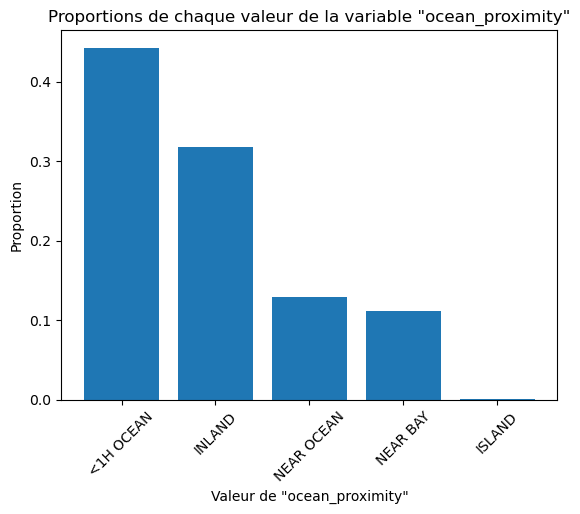

In [11]:

# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Création du barplot
plt.bar(x=prop_counts.index, height=prop_counts)
plt.xticks(rotation=45)
plt.xlabel('Valeur de "ocean_proximity"')
plt.ylabel('Proportion')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

# Analyses bivariées et sélection des variables pertinentes

## Corrélation entre les variables numériques

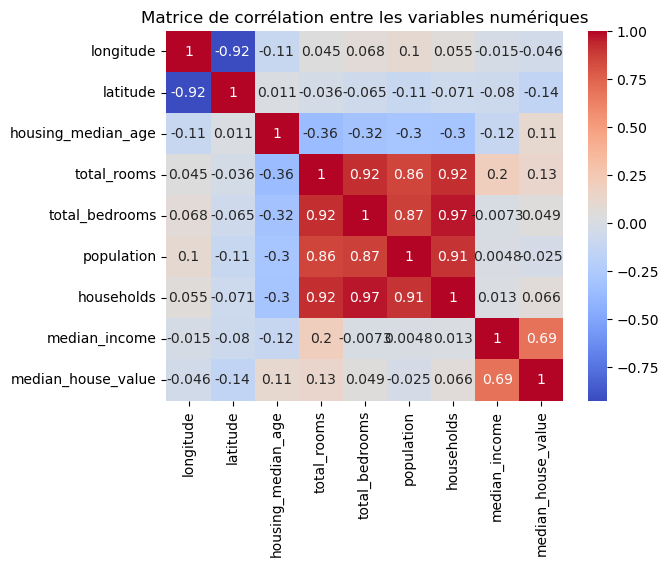

In [12]:
import seaborn as sns
# Corrélation entre les variables numériques
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation entre les variables numériques')
plt.show()


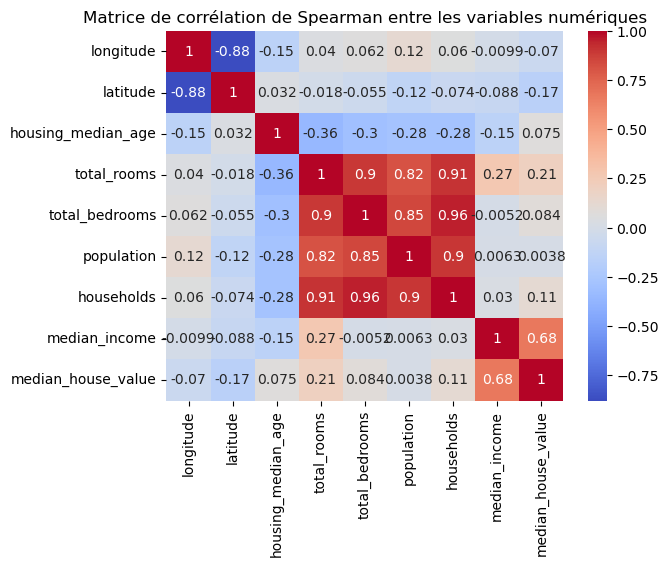

In [13]:
# Sélection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns
# Calcul de la matrice de corrélation de Spearman
corr_matrix = data[num_vars].corr(method='spearman')

# Affichage de la matrice de corrélation de Spearman
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation de Spearman entre les variables numériques')
plt.show()

## Relation entre la variable cible 'median_house_value' et les variables numériques

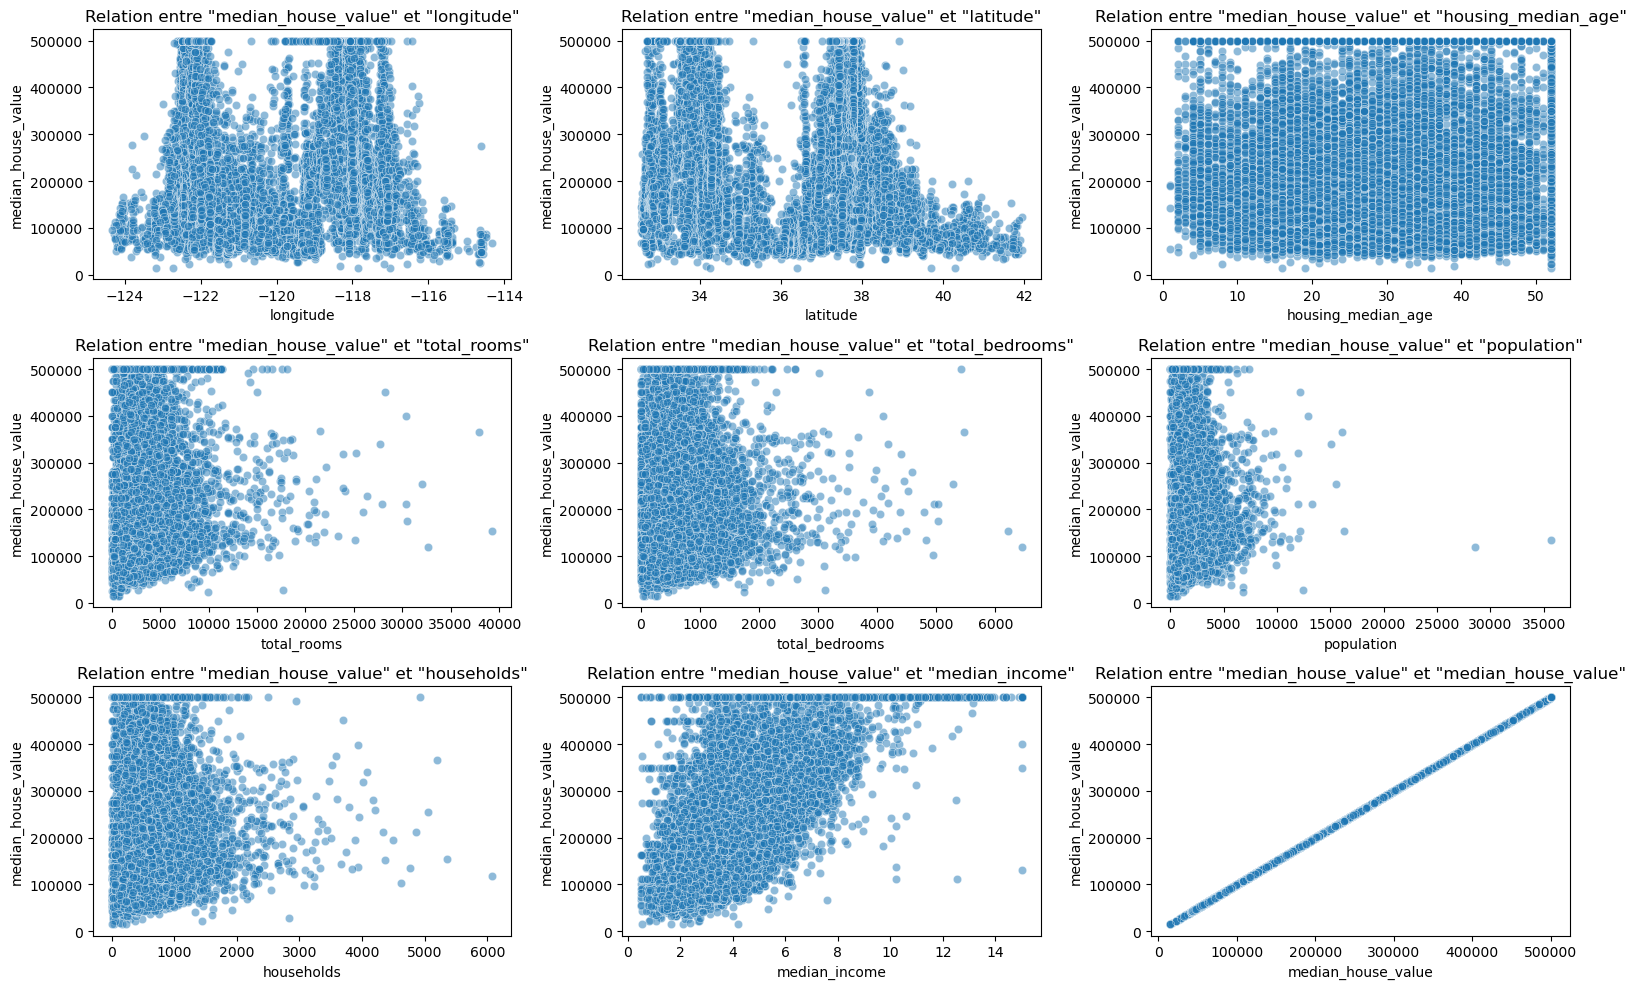

In [14]:
# Sélection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns

# Calcul de la taille de la matrice des subplots en fonction du nombre de variables numériques
n_cols = 3
n_rows = int(np.ceil(len(num_vars) / n_cols))

# Affichage des scatterplots pour chaque variable numérique sur une même figure avec des subplots
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 10))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.scatterplot(x=var, y='median_house_value', data=data, alpha=0.5, ax=axs[i])
    axs[i].set_title('Relation entre "median_house_value" et "{}"'.format(var))

# Ajout des titres et des étiquettes des axes
plt.tight_layout()
plt.show()


## Relation entre la variable cible 'median_house_value' et la variable catégorielle 'ocean_proximity'


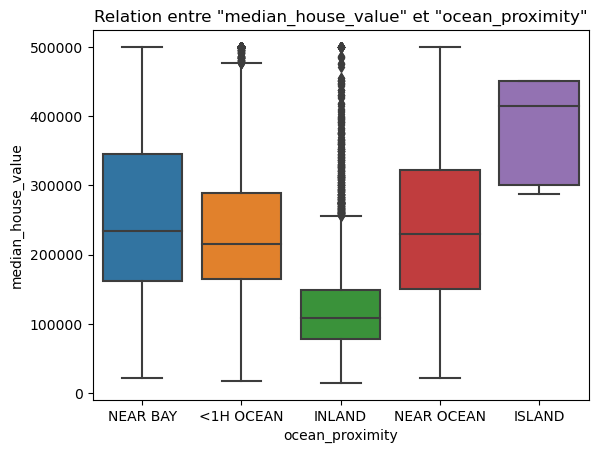

In [15]:
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)
plt.title('Relation entre "median_house_value" et "ocean_proximity"')
plt.show()


## Relation entre les variables numériques

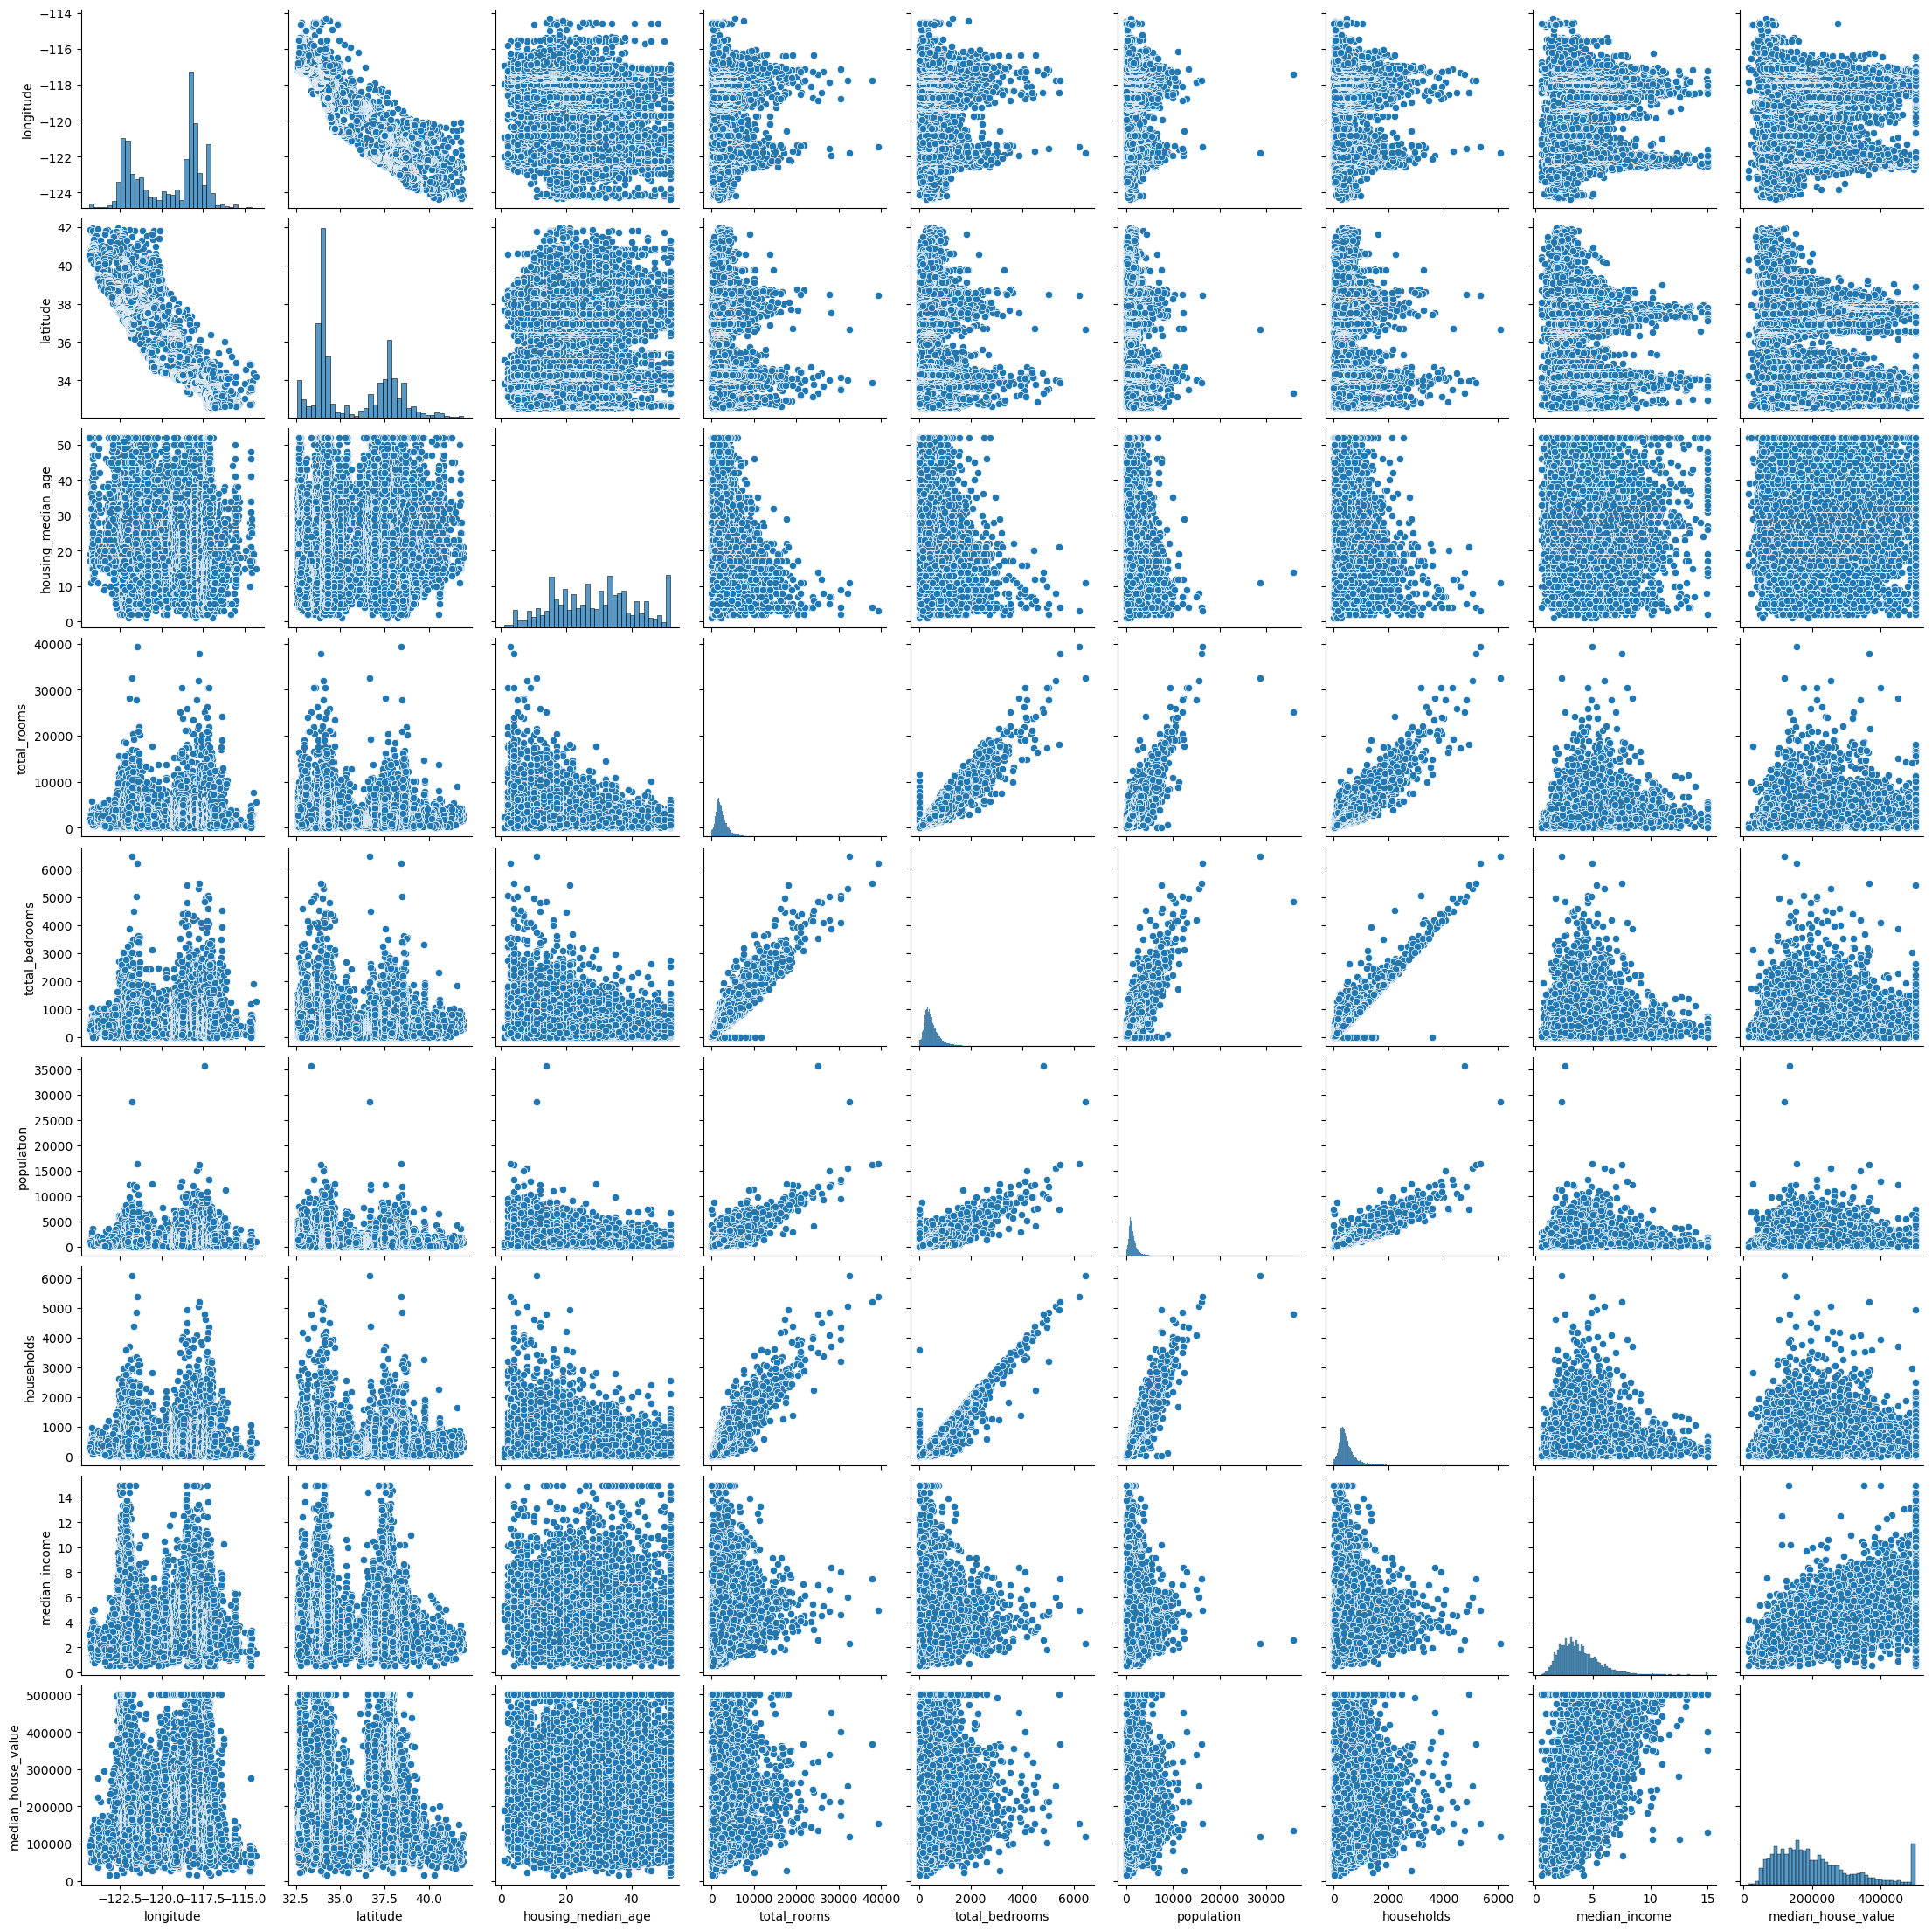

In [16]:
sns.pairplot(data[num_vars])
plt.show()

# Modélisation du prix du bien immobilier

## Variables

In [17]:
from sklearn.preprocessing import OneHotEncoder
# Sélection des variables catégorielles
cat_vars = ['ocean_proximity']

# Encodage binaire des variables catégorielles
encoder = OneHotEncoder(sparse=False)
cat_data = pd.DataFrame(encoder.fit_transform(data[cat_vars]))
cat_data.columns = encoder.get_feature_names_out(cat_vars)

# Remplacement des variables catégorielles par les variables encodées
data = pd.concat([data.drop(cat_vars, axis=1), cat_data], axis=1)
data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374.0,845,330,1.5603,78100,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697,150.0,356,114,2.5568,77100,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254,485.0,1007,433,1.7000,92300,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860,409.0,741,349,1.8672,84700,0.0,1.0,0.0,0.0,0.0


In [18]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374.0,845,330,1.5603,78100,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697,150.0,356,114,2.5568,77100,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254,485.0,1007,433,1.7000,92300,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860,409.0,741,349,1.8672,84700,0.0,1.0,0.0,0.0,0.0


In [19]:
# Séparation des données en variables explicatives et variable cible
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [20]:
y

0        452600
1        358500
2        352100
3        341300
4        342200
          ...  
20635     78100
20636     77100
20637     92300
20638     84700
20639     89400
Name: median_house_value, Length: 20640, dtype: int64

## Diviser la base en train en test

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Arbre de régression non optimisé

In [22]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

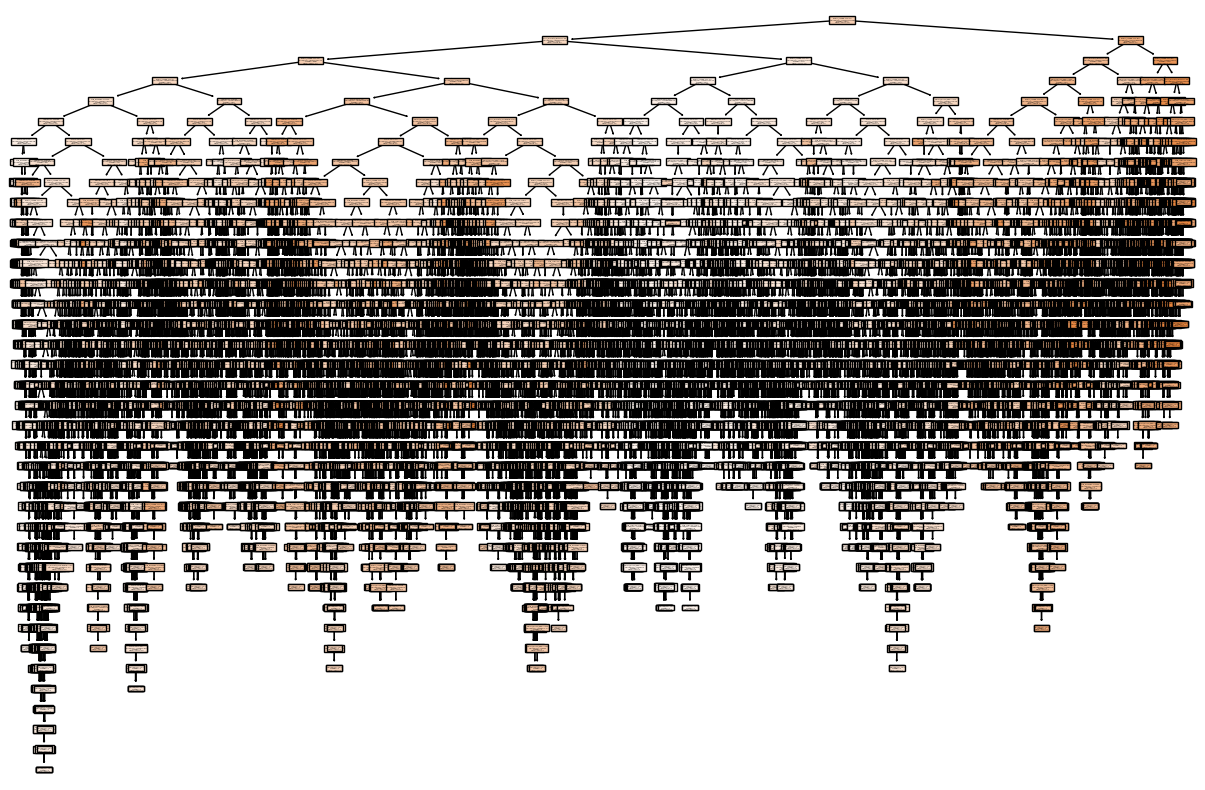

In [23]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

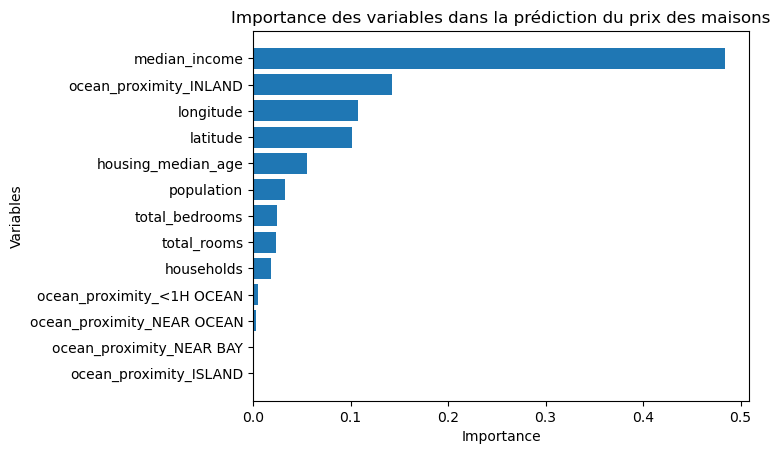

In [24]:
# Affichage de l'importance des variables
importances = pd.Series(tree.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [25]:

from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score,r2_score,mean_squared_error


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

          Apprentissage          Test
Métrique                             
RMSE                0.0  70713.309671
MAE                 0.0  44382.698159
MedAE               0.0  25300.000000
R2                  1.0      0.618411
EVS                 1.0      0.618453


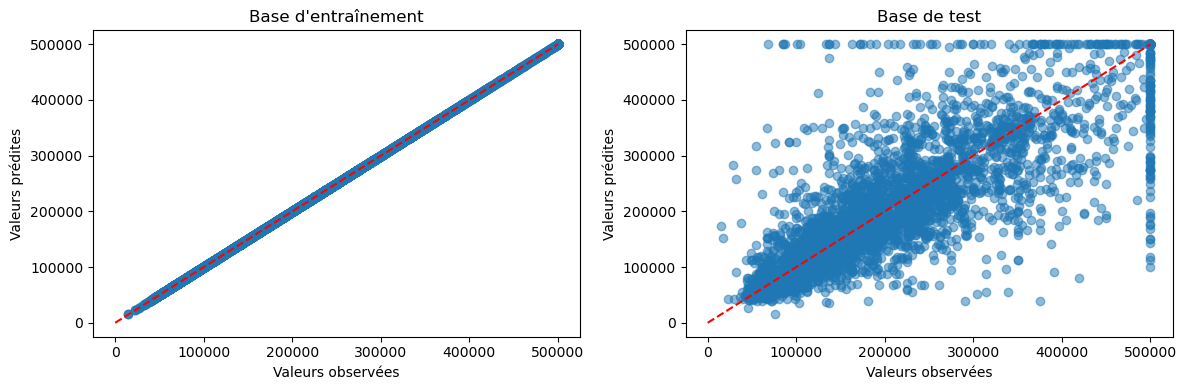

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entraînement
y_train_pred = tree.predict(X_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entraînement')

# Graphique pour la base de test
y_test_pred = tree.predict(X_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

## Arbre optimisé avec un élagage (prunning)

Profondeur optimale : 9


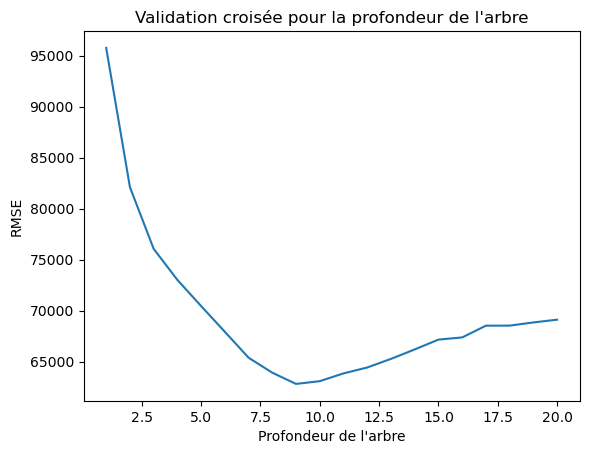

In [27]:
from sklearn.model_selection import GridSearchCV

# Définition de la grille de paramètres
param_grid = {'max_depth': np.arange(1, 21)}

# Instanciation de l'estimateur de l'arbre de décision
tree = DecisionTreeRegressor(random_state=42)

# Instanciation de l'objet GridSearchCV
grid_tree = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')

# Entraînement de l'objet GridSearchCV
grid_tree.fit(X_train, y_train)

# Affichage de la profondeur optimale
print("Profondeur optimale :", grid_tree.best_params_['max_depth'])

# Affichage de la courbe de validation croisée pour la profondeur de l'arbre
plt.plot(param_grid['max_depth'], np.sqrt(-grid_tree.cv_results_['mean_test_score']))
plt.xlabel('Profondeur de l\'arbre')
plt.ylabel('RMSE')
plt.title('Validation croisée pour la profondeur de l\'arbre')
plt.show()

In [28]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_optimal = DecisionTreeRegressor(max_depth=grid_tree.best_params_['max_depth'], random_state=42)
tree_optimal.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=9, random_state=42)

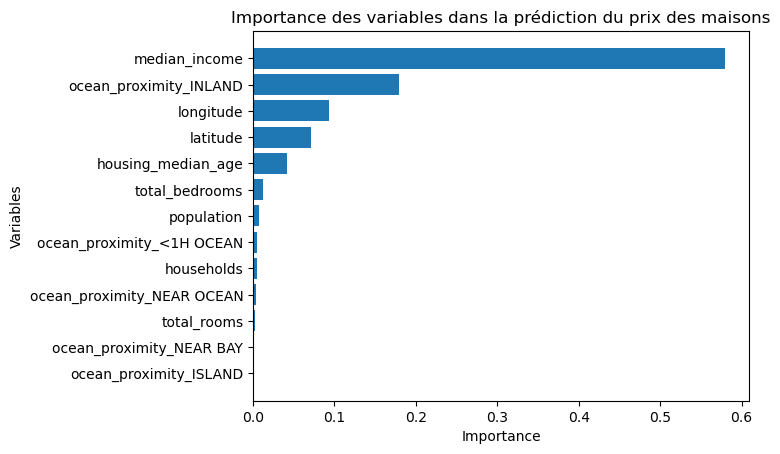

In [29]:
# Affichage de l'importance des variables
importances = pd.Series(tree_optimal.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

In [30]:
# Afficher l'arbre optimal

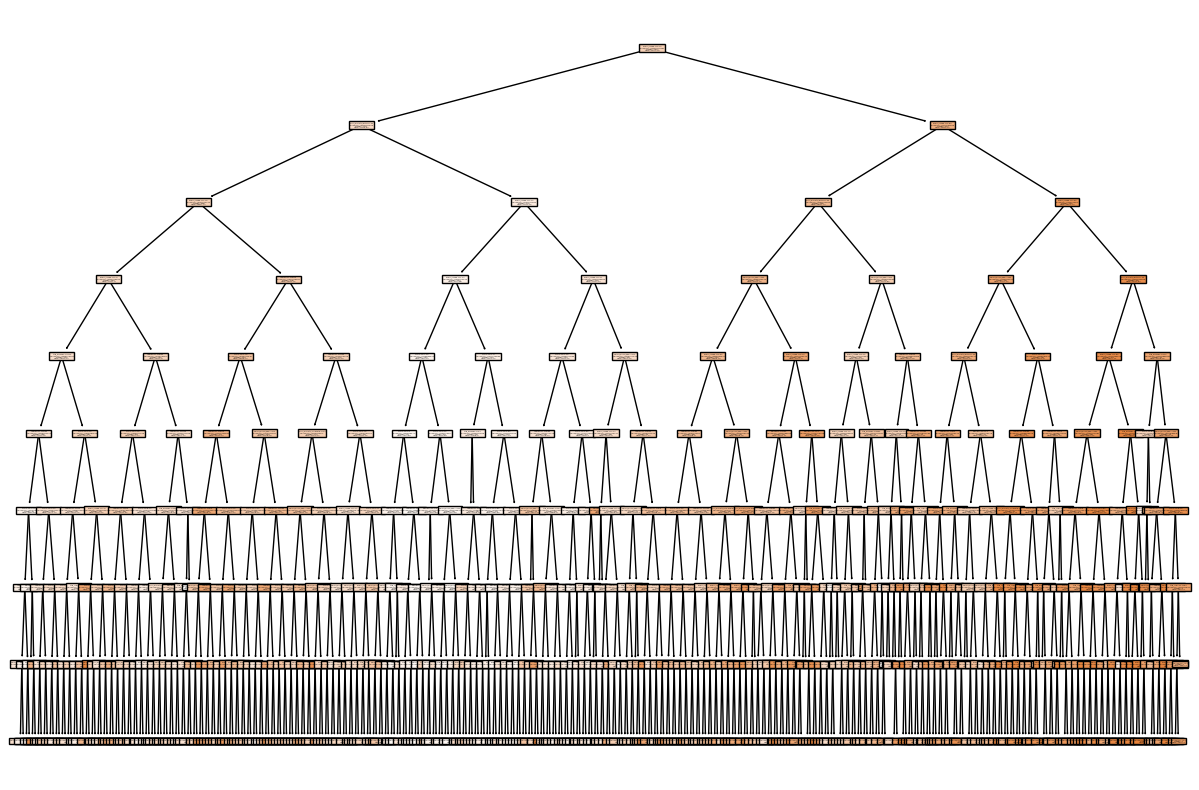

In [31]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree_optimal, feature_names=X_train.columns, filled=True)
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree_optimal.predict(X_train)
y_test_pred = tree_optimal.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

          Apprentissage          Test
Métrique                             
RMSE       52623.909413  64193.768674
MAE        36242.280327  41999.068763
MedAE      25005.760624  27808.855498
R2             0.792840      0.685530
EVS            0.792840      0.685584


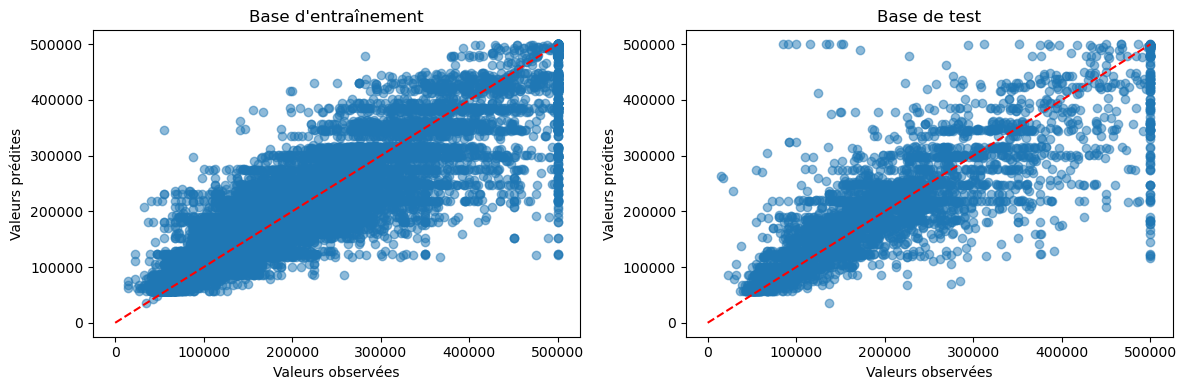

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entraînement
y_train_pred = tree_optimal.predict(X_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entraînement')

# Graphique pour la base de test
y_test_pred = tree_optimal.predict(X_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

## Tester une autre coupure de l'arbre

In [34]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_other = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_other.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

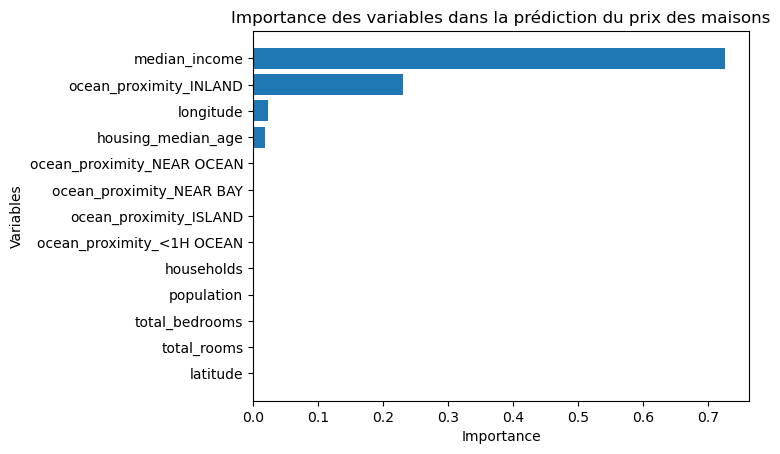

In [35]:
# Affichage de l'importance des variables
importances = pd.Series(tree_other.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

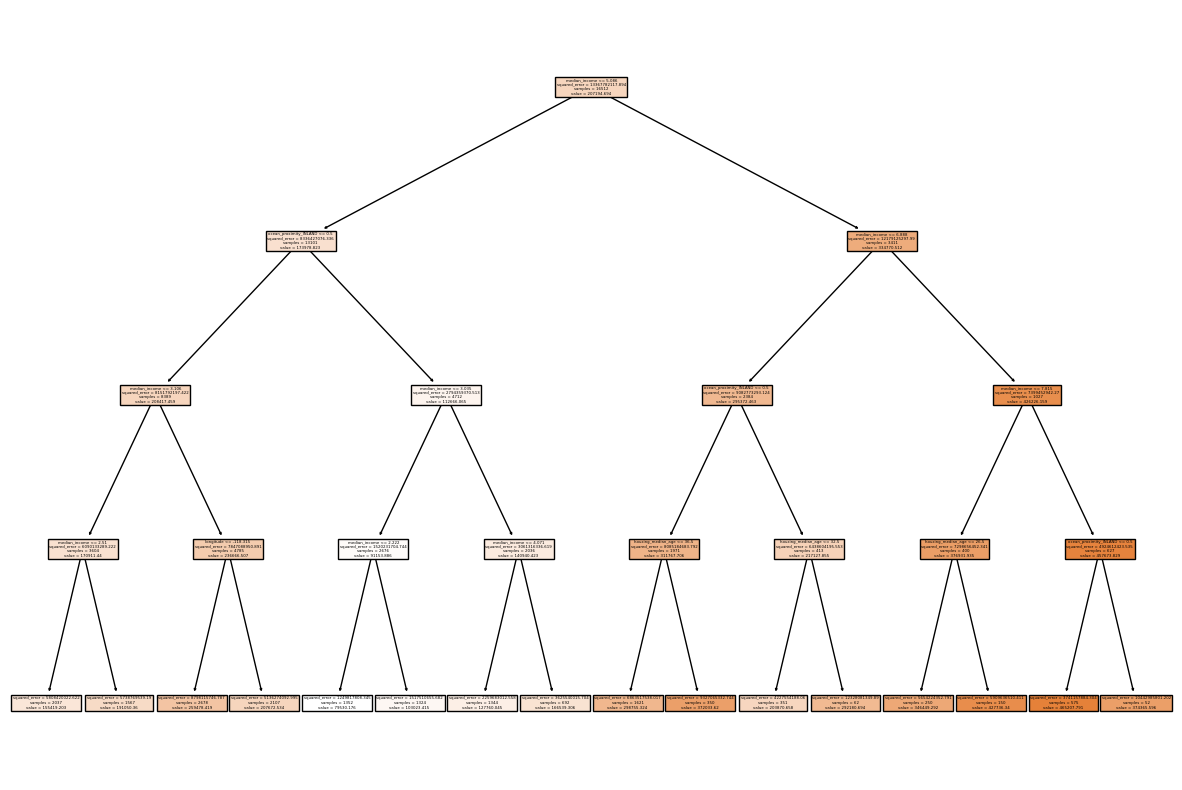

In [36]:
# Affichage de l'arbre
plt.figure(figsize=(15,10))
plot_tree(tree_other, feature_names=X_train.columns, filled=True)
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score


# Prédiction sur la base d'apprentissage et la base de test
y_train_pred = tree_other.predict(X_train)
y_test_pred = tree_other.predict(X_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats dans un tableau
results = pd.DataFrame({'Métrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'], 
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs], 
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Métrique', inplace=True)
print(results)

          Apprentissage          Test
Métrique                             
RMSE       72204.591609  73811.562991
MAE        51994.909367  52474.097859
MedAE      36619.202749  36011.087006
R2             0.609995      0.584241
EVS            0.609995      0.584272


# QUIZZ



1. Quel est l'objectif principal de l'optimisation de l'arbre de régression ?
   - a) Trouver la profondeur maximale de l'arbre
   - b) Trouver les critères optimaux pour la sélection des attributs
   - c) Minimiser l'erreur quadratique moyenne
   - d) Maximiser l'expliquabilité de l'arbre

2. Comment peut-on éviter le surajustement de l'arbre de régression ?
   - a) En augmentant la profondeur maximale de l'arbre
   - b) En réduisant la profondeur maximale de l'arbre
   - c) En choisissant un critère de sélection d'attributs qui favorise la complexité de l'arbre
   - d) En augmentant la taille du jeu de données d'entraînement

3. Quel est le critère de sélection d'attributs le plus communément utilisé pour l'arbre de régression en Python ?
   - a) mse
   - b) gini
   - c) entropy
   - d) friedman_mse

4. Comment peut-on trouver la profondeur maximale optimale de l'arbre de régression en Python ?
   - a) En utilisant la validation croisée
   - b) En utilisant la méthode RFE (Recursive Feature Elimination)
   - c) En utilisant le critère de Bayes
   - d) En choisissant la profondeur maximale manuellement



# Modèle de Forêt Aléatoire pour la régressionn

## Préparation des données pour le modèle

In [ ]:


# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Premier modèle sans optimisation

### Estimation du modèle

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, explained_variance_score


# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

### Prédiction sur la base train et la base test

In [40]:

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### Evaluation des performances

In [41]:

# Calcul des métriques de performance
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rms_train = mean_squared_error(y_train, y_train_pred, squared=False)
rms_test = mean_squared_error(y_test, y_test_pred, squared=False)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Affichage des résultats
performance_table = pd.DataFrame({
    'Métrique': ['R²', 'RMS', 'Score expliqué'],
    'Ensemble d\'entraînement': [r2_train, rms_train, explained_var_train],
    'Ensemble de test': [r2_test, rms_test, explained_var_test]
})
print(performance_table)

         Métrique  Ensemble d'entraînement  Ensemble de test
0              R²                 0.975554          0.811185
1             RMS             18077.297213      49741.836573
2  Score expliqué                 0.975555          0.811286


### Importance des variables

In [43]:
# Obtenir l'importance des variables
importance = model.feature_importances_

# Création d'un DataFrame pour afficher l'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage de l'importance des variables
print(importance_df)

                      Variable  Importance
7                median_income    0.490642
9       ocean_proximity_INLAND    0.140925
0                    longitude    0.105889
1                     latitude    0.101597
2           housing_median_age    0.051935
5                   population    0.032573
4               total_bedrooms    0.023819
3                  total_rooms    0.023366
6                   households    0.018367
12  ocean_proximity_NEAR OCEAN    0.006336
8    ocean_proximity_<1H OCEAN    0.003386
11    ocean_proximity_NEAR BAY    0.000711
10      ocean_proximity_ISLAND    0.000455


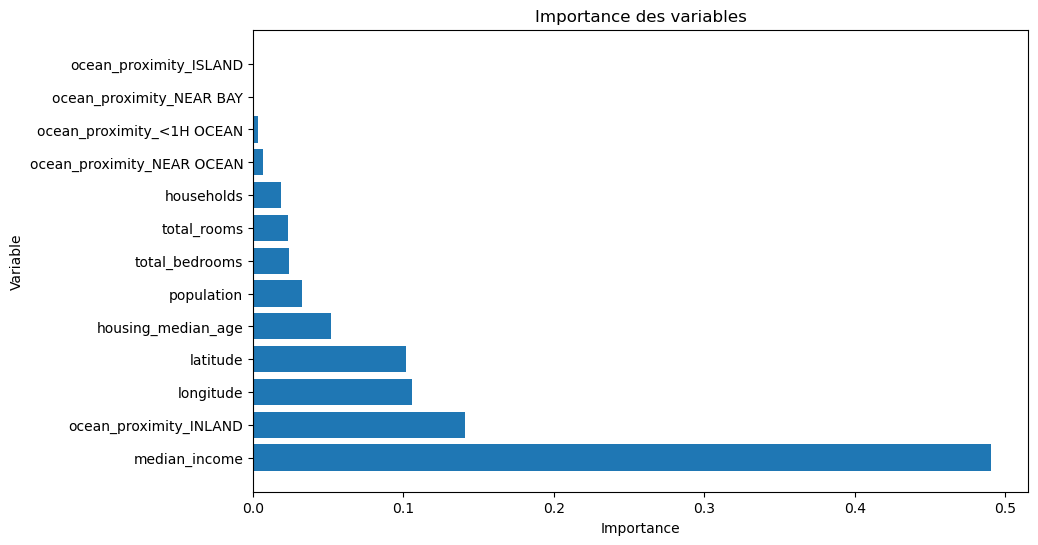

In [44]:
# Graphique de l'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

## Modèle avec optimisation par validation croisée

### Estimation du modèle

In [47]:

# Définir les paramètres à tester
param_grid = {
    'n_estimators': [100, 500],
     'max_depth': [None, 5 ,10]
}

# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(random_state=42)

# Recherche par grille pour optimiser les paramètres
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='r2', cv=5)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres : ", grid_search.best_params_)



Meilleurs paramètres :  {'max_depth': None, 'n_estimators': 500}


### Prédiction sur la base train et la base test

In [48]:
# Obtenir le meilleur modèle
best_model = grid_search.best_estimator_

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)


### Evaluation des performances

In [49]:

# Calcul des métriques d'évaluation
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Création du tableau de résultats
evaluation_table = pd.DataFrame({
    'Métrique': ['R²', 'MSE', 'Score expliqué'],
    'Ensemble d\'entraînement': [r2_train, mse_train, explained_var_train],
    'Ensemble de test': [r2_test, mse_test, explained_var_test]
})
# Affichage du tableau de résultats
print(evaluation_table)

         Métrique  Ensemble d'entraînement  Ensemble de test
0              R²             9.763033e-01      8.133972e-01
1             MSE             3.167729e+08      2.445260e+09
2  Score expliqué             9.763056e-01      8.134948e-01


### Importance des variables

                      Variable  Importance
7                median_income    0.489756
9       ocean_proximity_INLAND    0.141501
0                    longitude    0.105832
1                     latitude    0.101102
2           housing_median_age    0.052501
5                   population    0.032789
3                  total_rooms    0.023870
4               total_bedrooms    0.023650
6                   households    0.018028
12  ocean_proximity_NEAR OCEAN    0.006371
8    ocean_proximity_<1H OCEAN    0.003501
11    ocean_proximity_NEAR BAY    0.000758
10      ocean_proximity_ISLAND    0.000341


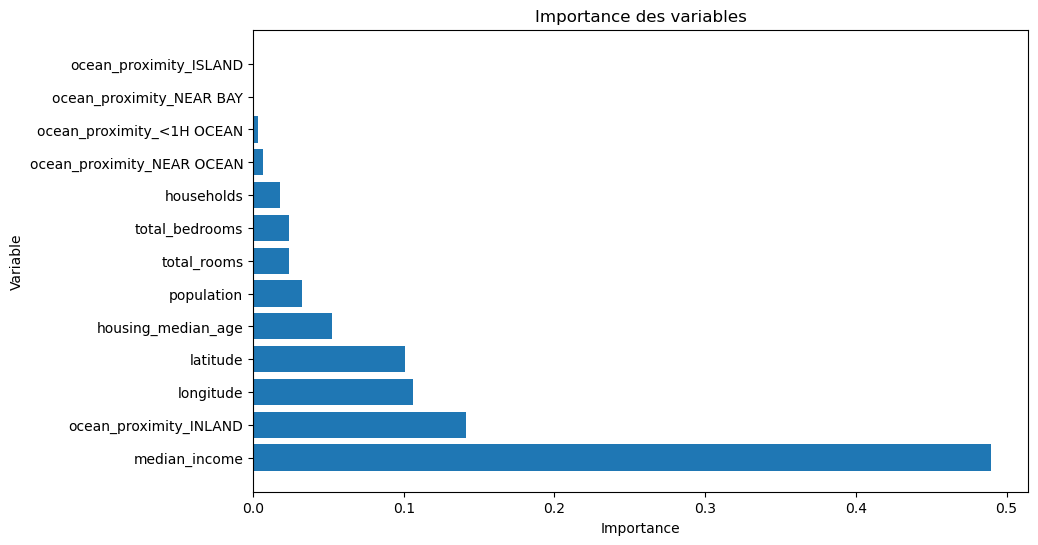

In [50]:
# Obtenir l'importance des variables
importance = best_model.feature_importances_

# Création du tableau d'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage du tableau d'importance des variables
print(importance_df)

# Graphique d'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

## Optimisation via RandomizedSearchCV



La classe `RandomizedSearchCV` de scikit-learn est utilisée pour effectuer une recherche aléatoire des meilleurs hyperparamètres d'un modèle d'apprentissage automatique. Elle permet d'explorer de manière efficace un grand espace de recherche d'hyperparamètres en échantillonnant un sous-ensemble aléatoire de combinaisons possibles.

#### Avantages de RandomizedSearchCV :

- **Efficacité** : RandomizedSearchCV réduit le temps de recherche en n'évaluant qu'un nombre fixe de combinaisons aléatoires d'hyperparamètres, ce qui le rend plus rapide que la recherche par grille (GridSearchCV) qui évalue toutes les combinaisons possibles.
- **Évite le surajustement** : En échantillonnant aléatoirement les hyperparamètres, RandomizedSearchCV évite le risque de surajustement en explorant une plus grande variété de combinaisons.
- **Évolutivité** : Il est possible d'ajuster la durée de la recherche en fixant le nombre d'itérations (n_iter) pour contrôler la quantité d'essais de combinaisons d'hyperparamètres.

#### Inconvénients de RandomizedSearchCV :

- **Pas de garantie de la meilleure solution** : Comme RandomizedSearchCV explore un sous-ensemble aléatoire d'hyperparamètres, il est possible qu'il ne trouve pas la meilleure combinaison possible. Il y a une chance qu'il manque certaines combinaisons qui pourraient donner de meilleurs résultats.
- **Dépendance de la distribution des échantillons** : Le choix de la distribution des échantillons pour les hyperparamètres peut avoir un impact sur les résultats. Si la distribution est mal choisie, certains hyperparamètres peuvent être sous-évalués ou négligés.
- **Moins de contrôle sur les valeurs spécifiques** : Contrairement à la recherche par grille, RandomizedSearchCV ne permet pas de spécifier des valeurs spécifiques pour les hyperparamètres. Il peut être plus difficile de cibler des valeurs spécifiques à tester.

En résumé, RandomizedSearchCV est une approche efficace et évolutive pour trouver de bons hyperparamètres dans un espace de recherche, mais il ne garantit pas la meilleure solution et nécessite une certaine exploration pour trouver les combinaisons les plus performantes.

Pour utiliser RandomizedSearchCV, il est important de bien comprendre ses avantages et ses inconvénients, ainsi que de l'adapter en fonction des besoins spécifiques du problème d'apprentissage automatique.


### Estimation du modèle

In [52]:
from sklearn.model_selection import  RandomizedSearchCV

# Définir la grille de paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Créer un modèle de forêt aléatoire de régression
model = RandomForestRegressor(random_state=42)

# Recherche aléatoire pour optimiser les paramètres
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, scoring='r2', n_iter=10, cv=5)
random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres : ", random_search.best_params_)


Meilleurs paramètres :  {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


### Prédiction sur la base train et test

In [53]:
# Obtenir le meilleur modèle
best_model = random_search.best_estimator_


# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)



In [54]:
### Evaluation des performances du modèle

In [55]:
# Calcul des métriques d'évaluation
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

explained_var_train = explained_variance_score(y_train, y_train_pred)
explained_var_test = explained_variance_score(y_test, y_test_pred)

# Création du tableau de performances
performance_table = pd.DataFrame({
    'Métrique': ['R²', 'MSE', 'Variance expliquée'],
    'Ensemble d\'entraînement': [r2_train, mse_train, explained_var_train],
    'Ensemble de test': [r2_test, mse_test, explained_var_test]
})

# Affichage du tableau de performances
print(performance_table)

             Métrique  Ensemble d'entraînement  Ensemble de test
0                  R²             9.643396e-01      8.124738e-01
1                 MSE             4.767007e+08      2.457361e+09
2  Variance expliquée             9.643431e-01      8.125749e-01


### Importance des variables

                      Variable  Importance
7                median_income    0.496984
9       ocean_proximity_INLAND    0.144107
0                    longitude    0.105303
1                     latitude    0.100906
2           housing_median_age    0.051119
5                   population    0.030708
4               total_bedrooms    0.021923
3                  total_rooms    0.021829
6                   households    0.016474
12  ocean_proximity_NEAR OCEAN    0.006409
8    ocean_proximity_<1H OCEAN    0.003223
11    ocean_proximity_NEAR BAY    0.000647
10      ocean_proximity_ISLAND    0.000367


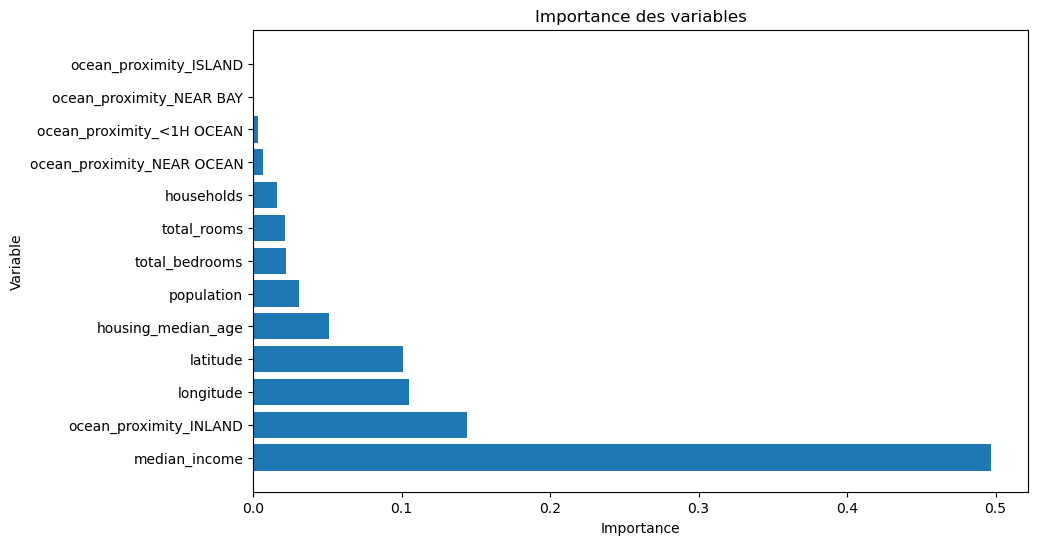

In [56]:
# Obtenir l'importance des variables
importance = best_model.feature_importances_

# Création du tableau d'importance des variables
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importance
})

# Tri des variables par ordre d'importance décroissante
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Affichage du tableau d'importance des variables
print(importance_df)

# Graphique d'importance des variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Importance des variables')
plt.show()

# Quizz

## Quiz sur les forêts aléatoires pour la régression en Python

1. Qu'est-ce qu'une forêt aléatoire de régression ?
   - A. Un algorithme utilisé pour la classification
   - B. Un modèle de régression linéaire
   - C. Une combinaison d'arbres de décision pour la régression
   - D. Un algorithme de clustering

2. Comment peut-on optimiser les paramètres d'une forêt aléatoire de régression ?
   - A. En utilisant une recherche par grille (grid search) ou une recherche aléatoire (random search)
   - B. En ajustant manuellement les paramètres jusqu'à obtenir de bons résultats
   - C. En utilisant une régression logistique pour trouver les meilleurs paramètres
   - D. En ne modifiant pas les paramètres par défaut

3. Qu'est-ce que l'importance des variables dans une forêt aléatoire de régression ?
   - A. C'est une mesure de la corrélation entre les variables explicatives
   - B. C'est une mesure de l'influence des variables sur la variable cible
   - C. C'est une mesure du nombre de fois où une variable est sélectionnée pour diviser les nœuds
   - D. C'est une mesure de la variabilité des prédictions du modèle

4. Comment évalue-t-on la performance d'une forêt aléatoire de régression ?
   - A. En utilisant le coefficient de détermination R²
   - B. En utilisant l'erreur quadratique moyenne (MSE)
   - C. En utilisant le score expliqué
   - D. Toutes les réponses précédentes
